In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

## Imports


In [2]:
import os, random, shutil, yaml
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import defaultdict

## Data

In [3]:
BASE     = "/kaggle/input/datasets/trainingdatapro/parking-space-detection-dataset"
IMG_DIR  = os.path.join(BASE, "images")
ANN_FILE = os.path.join(BASE, "annotations.xml")
OUT_DIR  = "/kaggle/working/parking_yolo"

SEED     = 42
VAL_SPLIT = 0.2
 
COLOR = {
    "free_parking_space":         "#4A90D9",   
    "not_free_parking_space":     "#E74C3C",   
    "partially_free_parking_space": "#F1C40F", 
}

In [4]:
tree = ET.parse(ANN_FILE)
root = tree.getroot()
 
annotations = defaultdict(list)
 
for image_elem in root.findall("image"):
    img_name = os.path.basename(image_elem.get("name"))  
 
    for box in image_elem.findall("box"):
        label = box.get("label")
        xtl   = float(box.get("xtl"))
        ytl   = float(box.get("ytl"))
        xbr   = float(box.get("xbr"))
        ybr   = float(box.get("ybr"))
        annotations[img_name].append({
            "label": label,
            "xtl": xtl, "ytl": ytl,
            "xbr": xbr, "ybr": ybr,
        })
 
    
    for polygon in image_elem.findall("polygon"):
        label = polygon.get("label")
        pts_str = polygon.get("points")          
        pts = [list(map(float, p.split(","))) for p in pts_str.split(";")]
        xs  = [p[0] for p in pts]
        ys  = [p[1] for p in pts]
        annotations[img_name].append({
            "label":  label,
            "xtl":    min(xs), "ytl": min(ys),
            "xbr":    max(xs), "ybr": max(ys),
            "points": pts,
        })

## Exploring the Data

In [5]:
total_images = len(annotations)
label_counts = defaultdict(int)
boxes_per_image = []
 
for img_name, boxes in annotations.items():
    boxes_per_image.append(len(boxes))
    for b in boxes:
        label_counts[b["label"]] += 1
 
total_boxes = sum(label_counts.values())
 
print(f"  Images with annotations : {total_images}")
print(f"  Total bounding boxes    : {total_boxes}")
print(f"  Avg boxes / image       : {np.mean(boxes_per_image):.1f}")
print(f"  Min / Max boxes / image : {min(boxes_per_image)} / {max(boxes_per_image)}")
print()
print("  Label breakdown:")
for label, cnt in sorted(label_counts.items(), key=lambda x: -x[1]):
    pct = 100 * cnt / total_boxes
    print(f"    {label:<40} {cnt:>5}  ({pct:.1f}%)")
 
print("\n  Image shapes:")
for img_name in list(annotations.keys())[:5]:
    path = os.path.join(IMG_DIR, img_name)
    if os.path.exists(path):
        img = Image.open(path)
        print(f"    {img_name}: {img.size[0]}x{img.size[1]}  mode={img.mode}")

  Images with annotations : 30
  Total bounding boxes    : 903
  Avg boxes / image       : 30.1
  Min / Max boxes / image : 6 / 81

  Label breakdown:
    not_free_parking_space                     624  (69.1%)
    free_parking_space                         273  (30.2%)
    partially_free_parking_space                 6  (0.7%)

  Image shapes:
    0.png: 1200x621  mode=RGB
    1.png: 650x487  mode=RGB
    10.png: 2560x1820  mode=RGB
    11.png: 1353x1041  mode=RGB
    12.png: 1920x1080  mode=RGB


## Only 6   partially_free_parking_space. Let's see them

Found 6 partially_free boxes across 5 images


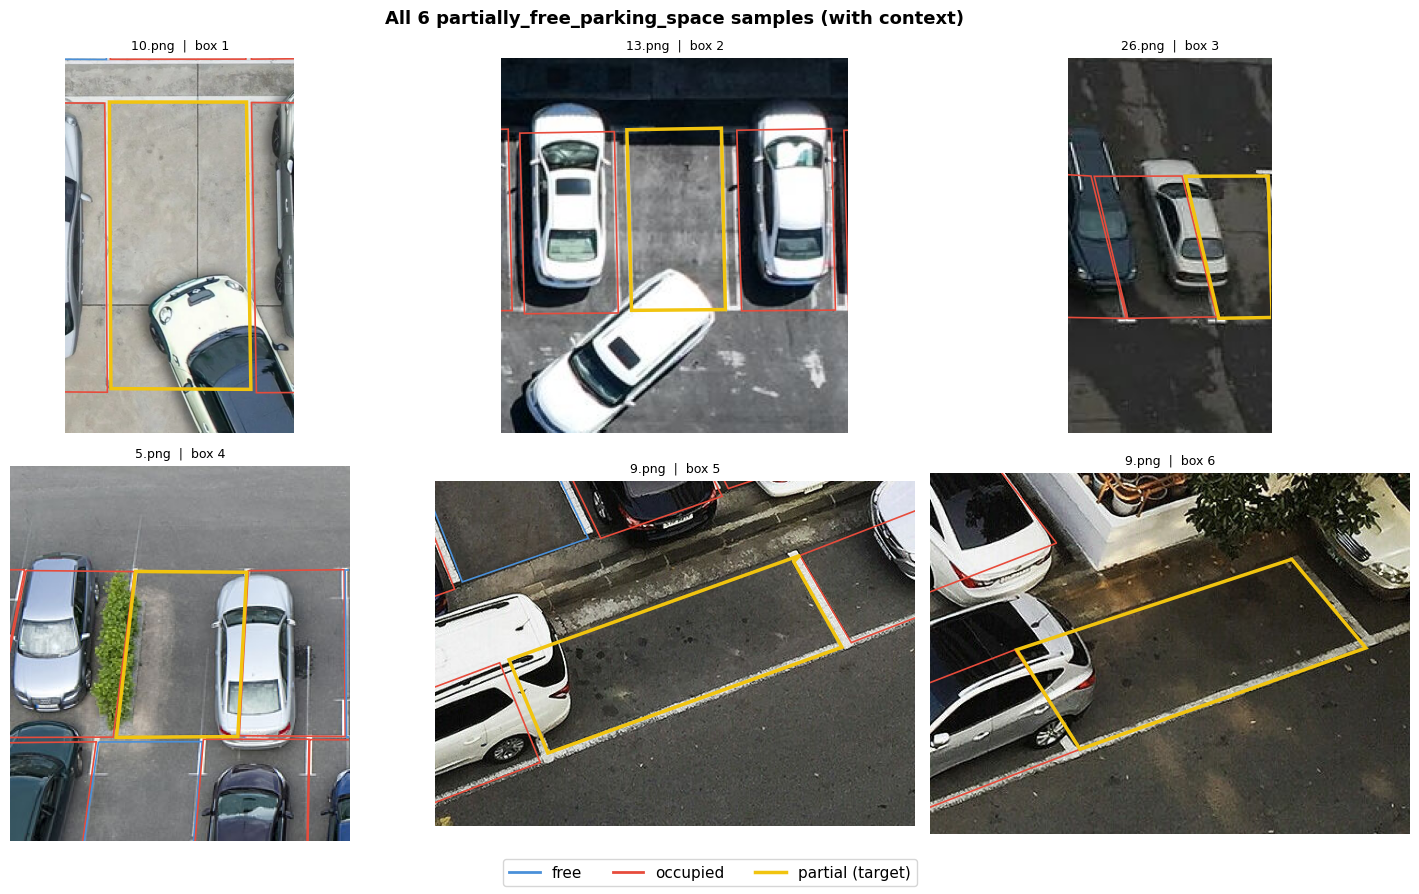

Saved: partial_samples.png


In [6]:

TARGET_LABEL = "partially_free_parking_space"
# ── Collect all partial boxes ──────────────────────────────────────────────
partial_samples = []   
for img_name, boxes in annotations.items():
    for b in boxes:
        if b["label"] == TARGET_LABEL:
            partial_samples.append((img_name, b))

print(f"Found {len(partial_samples)} partially_free boxes "
      f"across {len(set(n for n,_ in partial_samples))} images")


# ── Plot each crop with context ────────────────────────────────────────────
PADDING = 80   

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, (img_name, target_box) in enumerate(partial_samples):
    ax = axes[idx]
    path = os.path.join(IMG_DIR, img_name)
    img = np.array(Image.open(path))
    H, W = img.shape[:2]

    # Crop region with padding
    x1 = max(0, int(target_box["xtl"]) - PADDING)
    y1 = max(0, int(target_box["ytl"]) - PADDING)
    x2 = min(W, int(target_box["xbr"]) + PADDING)
    y2 = min(H, int(target_box["ybr"]) + PADDING)
    crop = img[y1:y2, x1:x2]

    ax.imshow(crop)
    ax.set_title(f"{img_name}  |  box {idx+1}", fontsize=9)
    ax.axis("off")

   
    for b in annotations[img_name]:
        bx1, by1, bx2, by2 = b["xtl"], b["ytl"], b["xbr"], b["ybr"]
        # Skip boxes entirely outside crop
        if bx2 < x1 or bx1 > x2 or by2 < y1 or by1 > y2:
            continue
        color = COLOR.get(b["label"], "white")
        lw = 2.5 if b["label"] == TARGET_LABEL else 1.2

        if "points" in b:
            shifted = [[p[0] - x1, p[1] - y1] for p in b["points"]]
            poly = plt.Polygon(shifted, fill=False, edgecolor=color, linewidth=lw)
            ax.add_patch(poly)
        else:
            rect = patches.Rectangle(
                (bx1 - x1, by1 - y1), bx2 - bx1, by2 - by1,
                linewidth=lw, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)

for ax in axes[len(partial_samples):]:
    ax.axis("off")

from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], color=COLOR["free_parking_space"],             lw=2, label="free"),
    Line2D([0], [0], color=COLOR["not_free_parking_space"],         lw=2, label="occupied"),
    Line2D([0], [0], color=COLOR["partially_free_parking_space"],   lw=2.5, label="partial (target)"),
]
fig.legend(handles=legend_elems, loc="lower center", ncol=3, fontsize=11)
plt.suptitle("All 6 partially_free_parking_space samples (with context)", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("partial_samples.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: partial_samples.png")

## Let's partially_free_parking_space to not free. We want our model to predict free spaces with more accuracy.

In [7]:
LABEL_MAP = {
    "free_parking_space":             0,
    "not_free_parking_space":         1,
    "partially_free_parking_space":   1,   #merged
}
CLASS_NAMES = ["free", "not_free"]
 
random.seed(SEED)

In [8]:
tree = ET.parse(ANN_FILE)
root = tree.getroot()
 
annotations = defaultdict(list)
for image_elem in root.findall("image"):
    img_name = os.path.basename(image_elem.get("name"))
    w_img = float(image_elem.get("width"))
    h_img = float(image_elem.get("height"))
 
    for box in image_elem.findall("box"):
        xtl = float(box.get("xtl")); ytl = float(box.get("ytl"))
        xbr = float(box.get("xbr")); ybr = float(box.get("ybr"))
        cx  = ((xtl + xbr) / 2) / w_img
        cy  = ((ytl + ybr) / 2) / h_img
        bw  = (xbr - xtl) / w_img
        bh  = (ybr - ytl) / h_img
        annotations[img_name].append((LABEL_MAP[box.get("label")], cx, cy, bw, bh))
 
    for poly in image_elem.findall("polygon"):
        pts = [list(map(float, p.split(","))) for p in poly.get("points").split(";")]
        xs, ys = [p[0] for p in pts], [p[1] for p in pts]
        xtl, ytl, xbr, ybr = min(xs), min(ys), max(xs), max(ys)
        cx  = ((xtl + xbr) / 2) / w_img
        cy  = ((ytl + ybr) / 2) / h_img
        bw  = (xbr - xtl) / w_img
        bh  = (ybr - ytl) / h_img
        annotations[img_name].append((LABEL_MAP[poly.get("label")], cx, cy, bw, bh))

In [9]:
all_images = list(annotations.keys())
random.shuffle(all_images)
n_val   = max(1, int(len(all_images) * VAL_SPLIT))
val_set = set(all_images[:n_val])
trn_set = set(all_images[n_val:])
print(f"Train: {len(trn_set)}  |  Val: {len(val_set)}")

Train: 24  |  Val: 6


In [10]:
for split, names in [("train", trn_set), ("val", val_set)]:
    os.makedirs(f"{OUT_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{OUT_DIR}/labels/{split}", exist_ok=True)
    for img_name in names:
        src = os.path.join(IMG_DIR, img_name)
        shutil.copy(src, f"{OUT_DIR}/images/{split}/{img_name}")
        stem = os.path.splitext(img_name)[0]
        with open(f"{OUT_DIR}/labels/{split}/{stem}.txt", "w") as f:
            for cls, cx, cy, bw, bh in annotations[img_name]:
                f.write(f"{cls} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")

In [11]:
data_cfg = {
    "path":  OUT_DIR,
    "train": "images/train",
    "val":   "images/val",
    "nc":    2,
    "names": CLASS_NAMES,
}
yaml_path = f"{OUT_DIR}/data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_cfg, f, default_flow_style=False)
print(f"data.yaml written to {yaml_path}")

data.yaml written to /kaggle/working/parking_yolo/data.yaml


## Giving class weight penalty because of class imbalance 

In [12]:
cls_pw = 273/630

In [ ]:
pip install ultralytics

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")
 
model.train(
    data      = yaml_path,
    epochs    = 50,
    imgsz     = 640,
    batch     = 8,
    seed      = SEED,
    # ── Augmentation: flips only, everything else off ──
    fliplr    = 0.5,   # horizontal flip
    flipud    = 0.5,   # vertical flip
    mosaic    = 0.0,
    mixup     = 0.0,
    degrees   = 0.0,
    translate = 0.0,
    scale     = 0.0,
    shear     = 0.0,
    perspective = 0.0,
    hsv_h     = 0.0,
    hsv_s     = 0.0,
    hsv_v     = 0.0,
    cls_pw    = cls_pw,
    project   = "/kaggle/working/runs",
    name      = "baseline_flip_only",
    exist_ok  = True,
    pretrained = True,
    verbose   = True,
)
 
print("\nDone. Results in /kaggle/working/runs/baseline_flip_only/")

## Plotting the Loss over training. Looks healthy

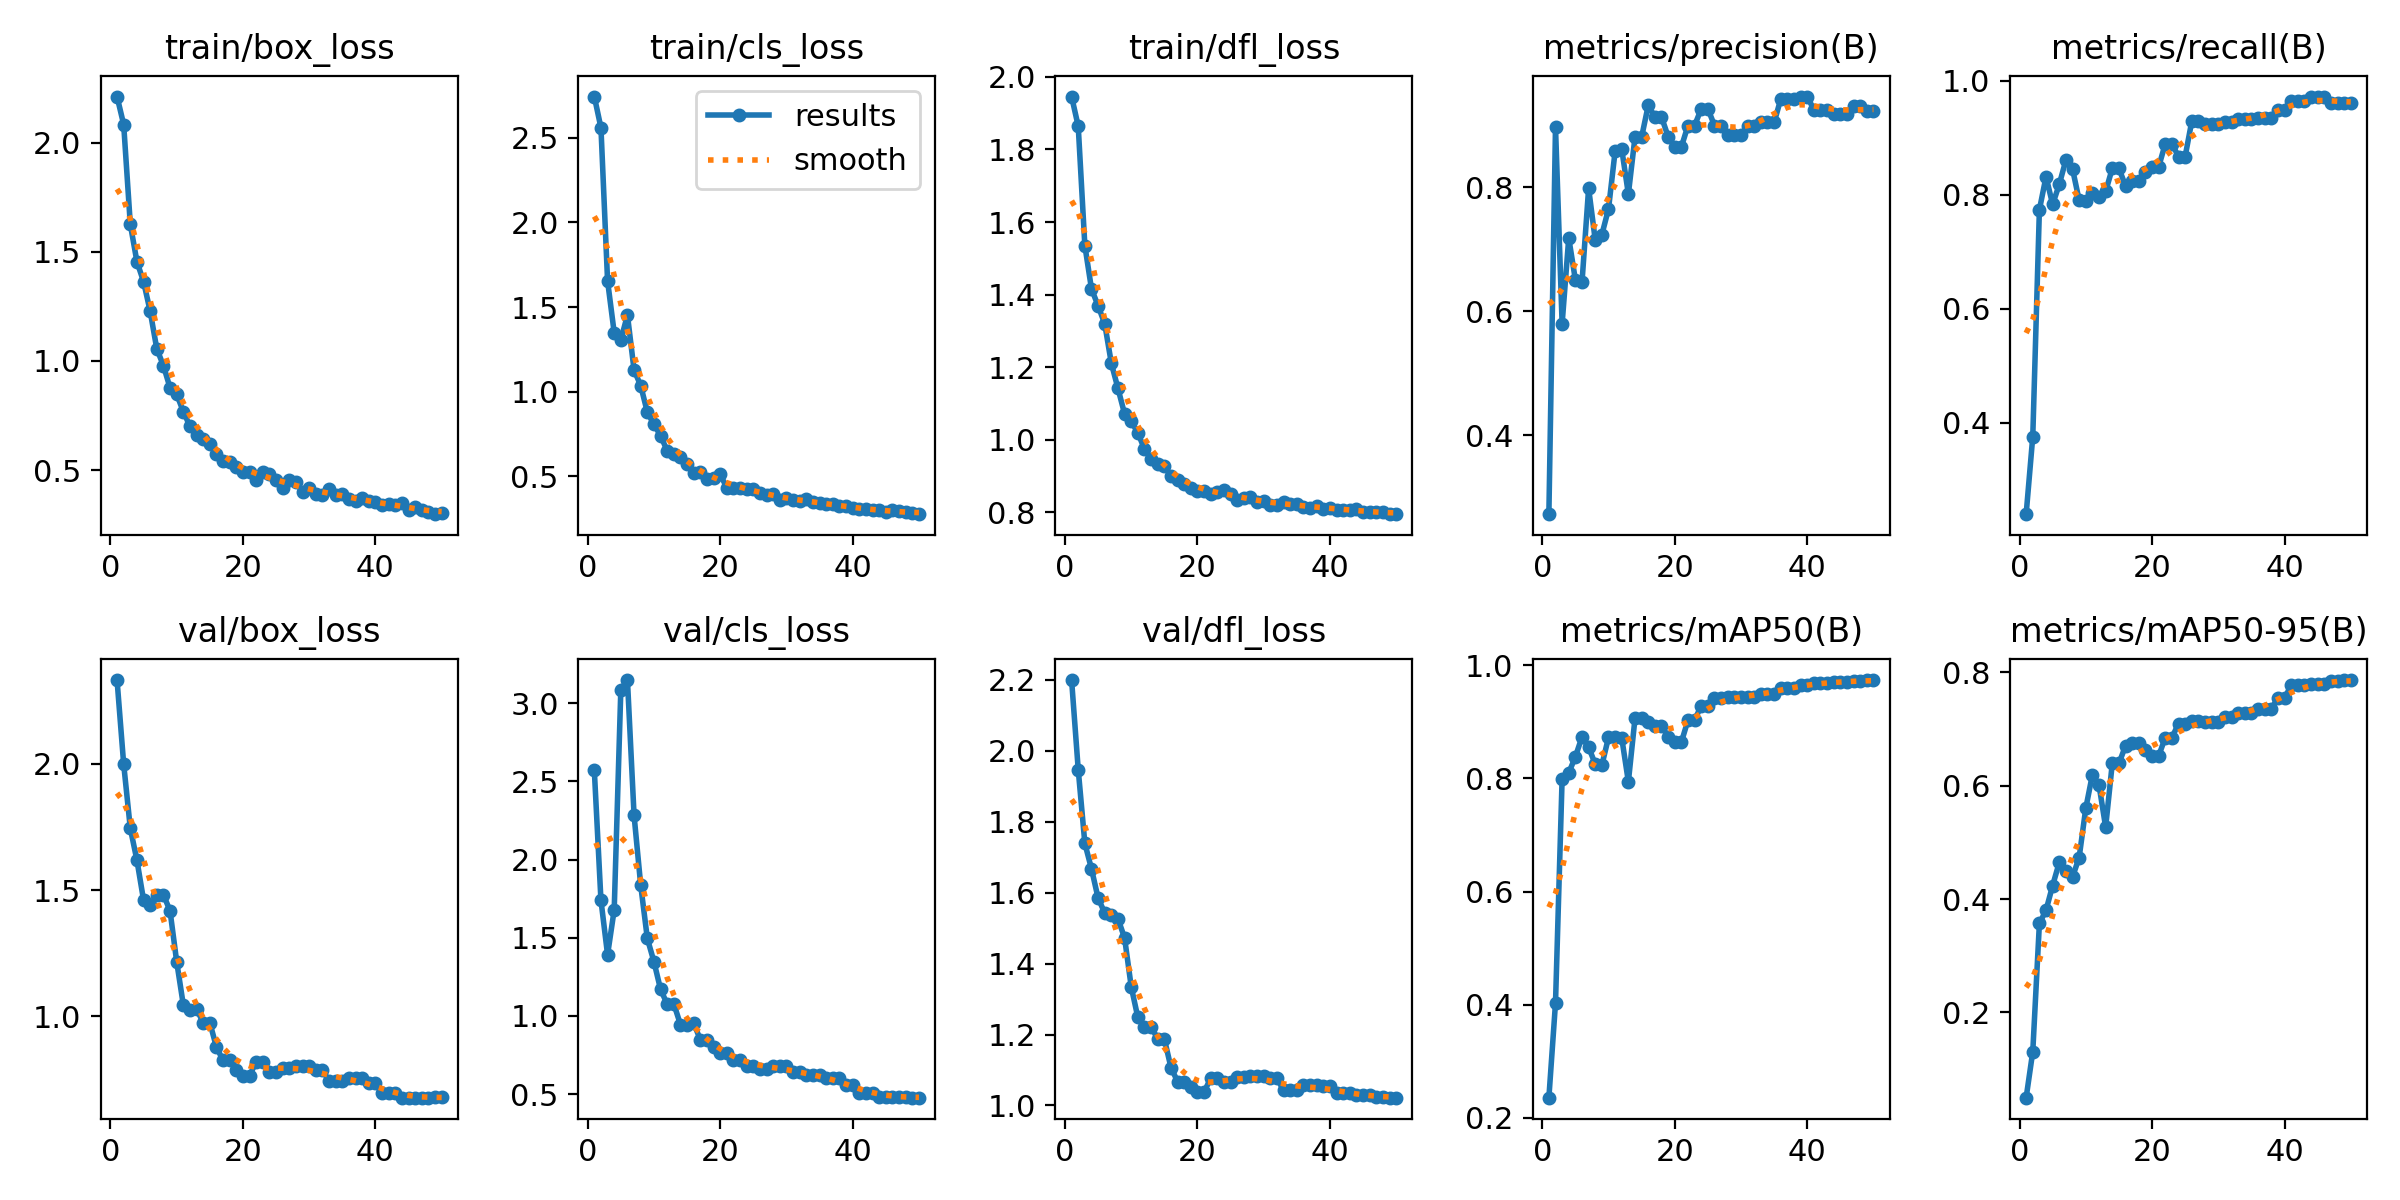

In [15]:
from IPython.display import Image as IPImage

results_plot = "/kaggle/working/runs/baseline_flip_only/results.png"
IPImage(results_plot)

In [16]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/baseline_flip_only/weights/best.pt")
metrics = model.val(data="/kaggle/working/parking_yolo/data.yaml", split="val")

print(f"mAP@50:      {metrics.box.map50:.4f}")
print(f"mAP@50-95:   {metrics.box.map:.4f}")
print(f"Precision:   {metrics.box.mp:.4f}")
print(f"Recall:      {metrics.box.mr:.4f}")
print("\nPer-class:")
for i, name in enumerate(["free", "not_free"]):
    print(f"  {name}: P={metrics.box.p[i]:.3f}  R={metrics.box.r[i]:.3f}  AP50={metrics.box.ap50[i]:.3f}")

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2647.6±857.1 MB/s, size: 306.1 KB)
val: Scanning /kaggle/working/parking_yolo/labels/val.cache... 6 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6/6 2.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.6it/s 0.2s
                   all          6        167      0.924      0.961      0.974      0.786
                  free          5         44      0.902      0.955      0.969      0.768
              not_free          6        123      0.945      0.967      0.978      0.805
Speed: 1.0ms preprocess, 15.7ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
mAP@50:      0.9739
mAP@50-95:   0.7864
Precision:   0.9236
Recall:      0.9610

Per-class:

## Great results. However, keep in mind that the dataset is very small. To be sure that model can differentiate free/not free spaces let's test it on random photo from the internet


image 1/1 /kaggle/input/datasets/danasydyk/parking-test/Screenshot 2026-06-29 at 11.16.40PM.png: 576x640 13 frees, 39 not_frees, 43.3ms
Speed: 2.7ms preprocess, 43.3ms inference, 1.4ms postprocess per image at shape (1, 3, 576, 640)


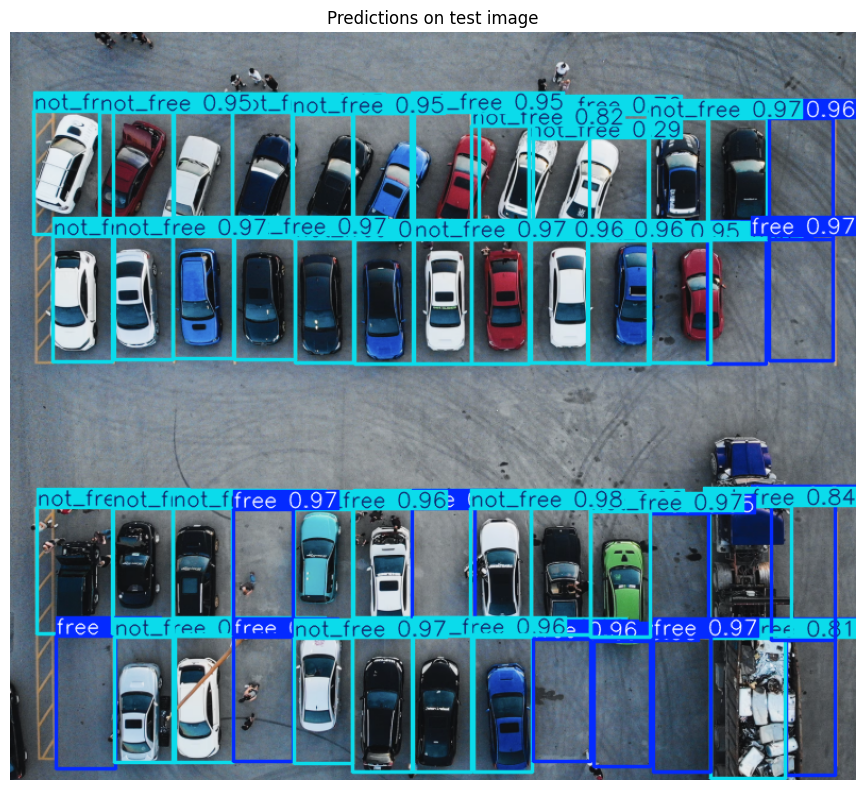

In [17]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

model = YOLO("/kaggle/working/runs/baseline_flip_only/weights/best.pt")

img_path = "/kaggle/input/datasets/danasydyk/parking-test/Screenshot 2026-06-29 at 11.16.40PM.png"
results = model.predict(img_path, conf=0.25, iou=0.45)

# Plot
annotated = results[0].plot()   
plt.figure(figsize=(14, 8))
plt.imshow(annotated[..., ::-1])  
plt.axis("off")
plt.title("Predictions on test image")
plt.tight_layout()
plt.show()

## Good results